In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from os import listdir, getcwd
import math
from rich.progress import track

In [ ]:
print(listdir(f"{getcwd()}/ROUND_2"))

# Manual inspection

In [3]:
df = pd.read_csv(f"{getcwd()}/ROUND_2/prices_round_2_day_1.csv", sep=';')

In [4]:
df.tail(5)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
19995,1,999700,ASH_COATED_OSMIUM,9985.0,13.0,9983.0,28.0,NaN,NaN,10001.0,13.0,10004.0,28.0,NaN,NaN,9993.0,0.0
19996,1,999800,INTARIAN_PEPPER_ROOT,13992.0,9.0,13989.0,24.0,NaN,NaN,14007.0,9.0,NaN,NaN,NaN,NaN,13999.5,0.0
19997,1,999800,ASH_COATED_OSMIUM,9985.0,10.0,9982.0,27.0,NaN,NaN,10001.0,10.0,10003.0,27.0,NaN,NaN,9993.0,0.0
19998,1,999900,ASH_COATED_OSMIUM,9985.0,15.0,9983.0,24.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0
19999,1,999900,INTARIAN_PEPPER_ROOT,13992.0,9.0,13989.0,25.0,NaN,NaN,14007.0,9.0,14011.0,25.0,NaN,NaN,13999.5,0.0


# Price merge all three days

In [5]:
df_1 = pd.read_csv(f"{getcwd()}/ROUND_2/prices_round_2_day_-1.csv", sep=';')
df_2 = pd.read_csv(f"{getcwd()}/ROUND_2/prices_round_2_day_0.csv", sep=';')
df_3 = pd.read_csv(f"{getcwd()}/ROUND_2/prices_round_2_day_1.csv", sep=';')

In [6]:
df_merge = pd.concat([df_1,df_2,df_3]) 

# Osmium

In [7]:
OSM_data = df_merge[df_merge["product"] == "ASH_COATED_OSMIUM"].copy()

In [8]:
OSM_best_bids = OSM_data["bid_price_1"]
OSM_best_asks = OSM_data["ask_price_1"]
OSM_mid_price = OSM_data["mid_price"]

In [9]:
OSM_mid_price_tweak = OSM_mid_price.replace(0.0, np.nan)
OSM_mid_price_tweak = OSM_mid_price_tweak.ffill()

## Bid analysis OSM

Seems like either 10003 or 10004 is a good top line

(9995.0, 10010.0)

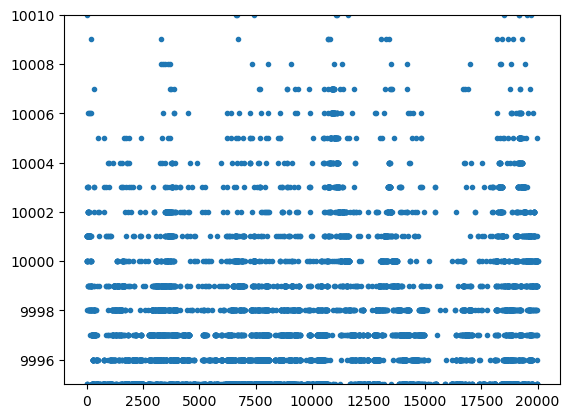

In [10]:
plt.plot(OSM_best_bids, marker = ".", linestyle='none')
plt.ylim(9995,10010)

## Ask analysis OSM

Ask seems like 9998 is okay lower would be better but this might get sparse

(9990.0, 10005.0)

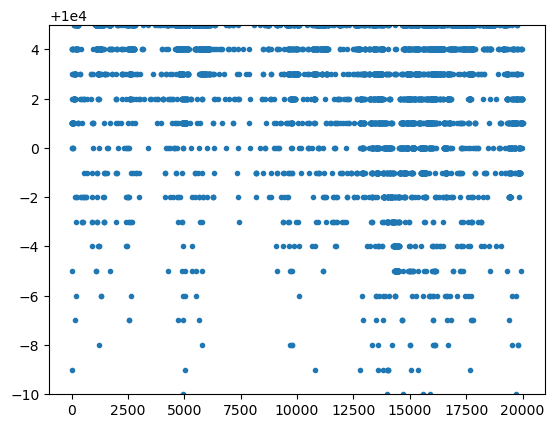

In [11]:
plt.plot(OSM_best_asks, marker = ".", linestyle='none')
plt.ticklabel_format(style="plain")
plt.ylim(9990,10005)


## Bid/Ask count and edge analysis

In [12]:
for val in range(9995,10001):
    print(f"Number of timestamps with a best ask at {val}: {(OSM_best_asks == val).sum()} counts")

Number of timestamps with a best ask at 9995: 95 counts
Number of timestamps with a best ask at 9996: 89 counts
Number of timestamps with a best ask at 9997: 116 counts
Number of timestamps with a best ask at 9998: 200 counts
Number of timestamps with a best ask at 9999: 354 counts
Number of timestamps with a best ask at 10000: 438 counts


In [13]:
for val in range(10000,10006):
    print(f"Number of timestamps with a best bid at {val}: {(OSM_best_bids == val).sum()} counts")

Number of timestamps with a best bid at 10000: 652 counts
Number of timestamps with a best bid at 10001: 455 counts
Number of timestamps with a best bid at 10002: 333 counts
Number of timestamps with a best bid at 10003: 263 counts
Number of timestamps with a best bid at 10004: 140 counts
Number of timestamps with a best bid at 10005: 116 counts


In [14]:
print(f"Total timestamps: {len(OSM_best_bids)}")

Total timestamps: 30000


In [15]:
OSM_mid_price_tweak.mean()

10000.879933333334

# Pepperroot

In [16]:
df_merge.head(2)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0


In [17]:
IPR_data = df_merge[df_merge["product"] == "INTARIAN_PEPPER_ROOT"].copy()

In [18]:
IPR_best_bids = IPR_data["bid_price_1"]
IPR_best_asks = IPR_data["ask_price_1"]
IPR_mid_price = IPR_data["mid_price"]

## Bid analysis IPR

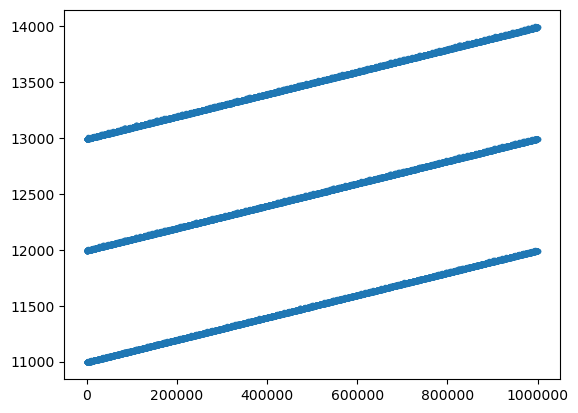

In [19]:
plt.plot(IPR_data["timestamp"], IPR_best_bids, marker = ".", linestyle='none')
plt.ticklabel_format(style="plain")
#plt.ylim(9995,10010)

## Ask analysis IPR

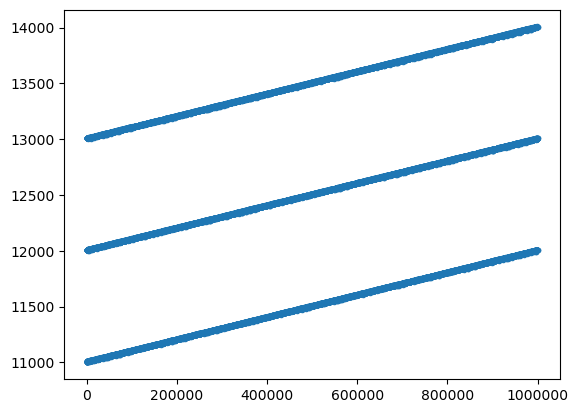

In [20]:
plt.plot(IPR_data["timestamp"], IPR_best_asks, marker = ".", linestyle='none')
plt.ticklabel_format(style="plain")
#plt.ylim(9995,10010)

## Price analysis IPR

In [21]:
IPR_day_0_data = IPR_data[IPR_data["day"] == 0].copy()

In [22]:
bids_0 = IPR_day_0_data["bid_price_1"]
asks_0 = IPR_day_0_data["ask_price_1"]
time = IPR_day_0_data["timestamp"]

(960000.0, 1000000.0)

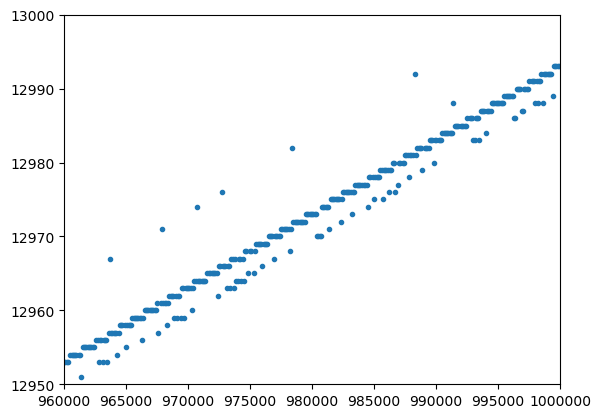

In [23]:
plt.plot(time, bids_0, marker = ".", linestyle='none')
plt.ticklabel_format(style="plain")
plt.ylim(12950,13000)
plt.xlim(960000,1000000)

# Manual Challenge game theory analysis

## Research function analysis

In [17]:
def research_func(x):
    return 200000 * np.log(1+x) / np.log(1+100)

def research_func_inverse(value):
    return np.exp((value/200000)*np.log(1+100)) - 1

def research_func_deriv(x):
    return 200000 / (np.log(101)*(1+x))

In [18]:
x_array = np.array(range(0,101))
val_array = research_func(x_array)
dx_val_array = research_func_deriv(x_array)

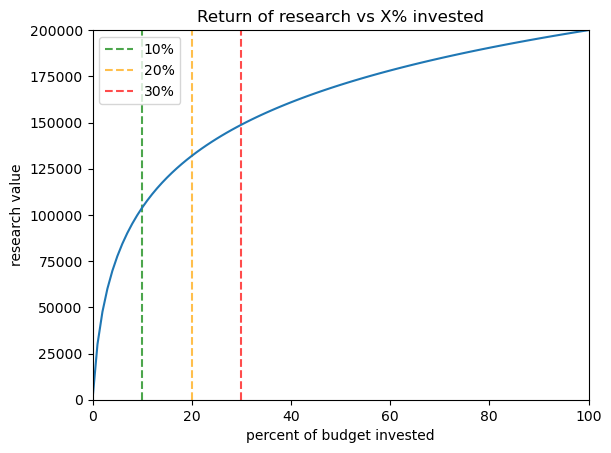

In [19]:
plt.vlines(10,0,200000, linestyle="dashed",color="green", label = "10%",alpha = 0.7)
plt.vlines(20,0,200000, linestyle="dashed",color="orange", label = "20%",alpha = 0.7)
plt.vlines(30,0,200000, linestyle="dashed",color="red", label = "30%",alpha = 0.7)
plt.plot(x_array,val_array)
plt.title("Return of research vs X% invested")
plt.ylabel("research value")
plt.xlabel("percent of budget invested")
plt.ylim(0,200000)
plt.xlim(0,100)
plt.legend()

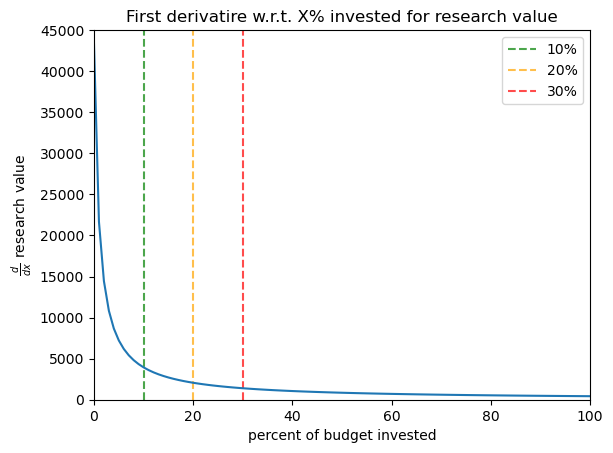

In [20]:
plt.vlines(10,0,45000, linestyle="dashed",color="green", label = "10%",alpha = 0.7)
plt.vlines(20,0,45000, linestyle="dashed",color="orange", label = "20%",alpha = 0.7)
plt.vlines(30,0,45000, linestyle="dashed",color="red", label = "30%",alpha = 0.7)
plt.plot(x_array,dx_val_array)
plt.title("First derivatire w.r.t. X% invested for research value")
plt.ylabel(r"$\frac{d}{dx}$ research value")
plt.xlabel("percent of budget invested")
plt.ylim(0,45000)
plt.xlim(0,100)
plt.legend()

In [21]:
for x in [1,3,5,8,10,15,20,30,40,50]:
    print(f"For {x}% invested, the research value is: {research_func(x)}")

For 1% invested, the research value is: 30038.09664473759
For 3% invested, the research value is: 60076.19328947518
For 5% invested, the research value is: 77647.35341968466
For 8% invested, the research value is: 95218.51354989414
For 10% invested, the research value is: 103914.74129648814
For 15% invested, the research value is: 120152.38657895036
For 20% invested, the research value is: 131936.85523979313
For 30% invested, the research value is: 148814.62756840335
For 40% invested, the research value is: 160930.66489392563
For 50% invested, the research value is: 170388.86063219848


## Scale function

In [22]:
def scale_func(x):
    return np.round(0+x/100*7,1)

In [23]:
scale_val_array = scale_func(x_array)

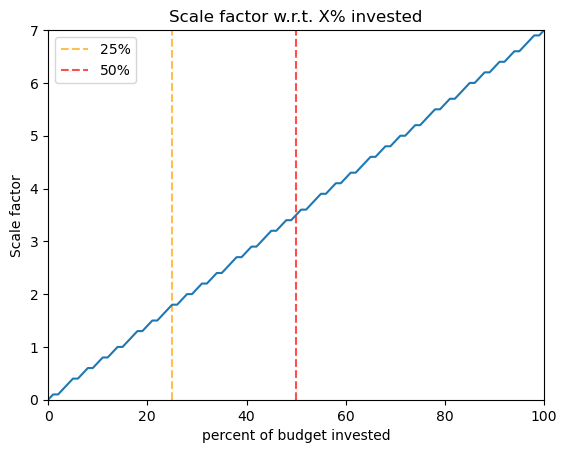

In [24]:
# plt.vlines(10,0,45000, linestyle="dashed",color="green", label = "10%",alpha = 0.7)
plt.vlines(25,0,45000, linestyle="dashed",color="orange", label = "25%",alpha = 0.7)
plt.vlines(50,0,45000, linestyle="dashed",color="red", label = "50%",alpha = 0.7)
plt.plot(x_array,scale_val_array)
plt.title("Scale factor w.r.t. X% invested")
plt.ylabel(r"Scale factor")
plt.xlabel("percent of budget invested")
plt.ylim(0,7)
plt.xlim(0,100)
plt.legend()

## Simple TradeOff (scale x research) @ manual params

Assumes a speed factor of 0.4 at 30%. More sophisticated analysis comes later

In [25]:
available_share = 70
estimated_speed_factor = 0.5

In [26]:
x_array_research = np.array(range(0,available_share+1))
x_array_scale = np.array(range(available_share,-1,-1))
val_research_array = research_func(x_array_research)
val_scale_array = scale_func(x_array_scale)

# Combines with assumption speed factor = 
val_comb = val_research_array * val_scale_array * estimated_speed_factor


Text(0.5, 0, 'X')

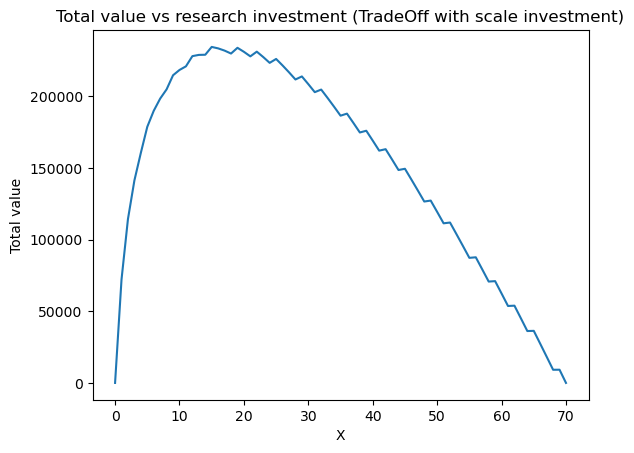

In [27]:
# plt.vlines(10,0,45000, linestyle="dashed",color="green", label = "10%",alpha = 0.7)
#plt.vlines(25,0,45000, linestyle="dashed",color="orange", label = "25%",alpha = 0.7)
#plt.vlines(50,0,45000, linestyle="dashed",color="red", label = "50%",alpha = 0.7)
plt.plot(x_array_research,val_comb)
plt.title("Total value vs research investment (TradeOff with scale investment)")
plt.ylabel(r"Total value")
plt.xlabel("X")
#plt.ylim(0,7)
#plt.xlim(0,100)
#plt.legend()

## TradeOff (scale x research) with speedfactor distribution sampling

Idea for now:
1. estimate a distribution for speed investments
2. sample from distribution to create an investment field
3. use a predetermined investment bid
4. determine factor from the bid vs the existing field
5. Create the payoff plot

Optional:
1. Run the idea above multiple times, each time with another speed investment
2. Create a 2D height map with payoff
3. Select optimal investment for speed, research and scale based on this

*Note: how non-offer (i.e. idle teams are handled affects the distribution greatly, so check this?*

In [28]:
def sample_speed_distribution(alpha, beta, N, 
                              low=10, high=70, 
                              round_int=True, 
                              snap_to_5_prob=0.0,
                              random_state=None):
    """
    Sample speed allocations S ~ low + (high-low)*Beta(alpha, beta)

    Parameters:
    - alpha, beta: Beta distribution parameters
    - N: number of samples
    - low, high: bounds of the interval (default [10, 70])
    - round_int: whether to round to integer percentages
    - snap_to_5_prob: probability of snapping to nearest multiple of 5
    - random_state: optional seed for reproducibility

    Returns:
    - numpy array of shape (N,)
    """

    rng = np.random.default_rng(random_state)

    # Step 1: sample Beta
    X = rng.beta(alpha, beta, size=N)

    # Step 2: scale to [low, high]
    S = low + (high - low) * X

    # Step 3: round to integers if desired
    if round_int:
        S = np.round(S)

    # Step 4: optionally snap some values to multiples of 5
    if snap_to_5_prob > 0:
        mask = rng.random(N) < snap_to_5_prob
        S[mask] = 5 * np.round(S[mask] / 5)

    return S.astype(int) if round_int else S


def compute_speed_factor(samples, your_bid):
    """
    Compute the speed multiplier for a given bid, based on sampled opponent bids.

    Parameters:
    - samples: numpy array of opponent speed allocations (integers)
    - your_bid: your chosen speed allocation (int)

    Returns:
    - speed multiplier (float between 0.1 and 0.9)
    """

    # Combine your bid with opponent samples
    all_bids = np.append(samples, your_bid)

    # Get unique sorted values (ascending)
    unique_vals = np.unique(all_bids)
    K = len(unique_vals)

    # Edge case: everyone picked the same value
    if K == 1:
        return 0.5  # neutral midpoint (you could also choose 0.9 or 0.1, but midpoint is fair)

    # Map each unique value to its rank
    # lowest → rank 1, highest → rank K
    val_to_rank = {val: rank for rank, val in enumerate(unique_vals, start=1)}

    # Get your rank
    rank = val_to_rank[your_bid]

    # Convert rank → multiplier in [0.1, 0.9]
    multiplier = 0.1 + 0.8 * (rank - 1) / (K - 1)

    return multiplier

def research_scale_tradeoff(available_investment, estimated_speed_factor):
    """
    Calaculates the total value of investment split V = Research * Scale_factor * Speed_factor

    Parameters:
    - available_investment: share of available investment for research and scale (0-100)
    - estimated_speed_factor: speed factor based on the sampling from the compute_speed_factor function (0.1-0.9)

    Returns:
    - list object with numpy arrays of investment share for research, and total value 
    """
    
    # Respective splits between research and scale
    x_array_research = np.array(range(0,available_investment+1))
    x_array_scale = np.array(range(available_investment,-1,-1))
    
    # Calculates the value for research and scale at each split
    val_research_array = research_func(x_array_research)
    val_scale_array = scale_func(x_array_scale)
    
    # Combines with assumption speed factor to calculate total value 
    val_comb = val_research_array * val_scale_array * estimated_speed_factor
    
    return [x_array_research, val_comb]


In [ ]:
def plot_irregular_surface(results, speed_values):
    X_all = []
    Y_all = []
    Z_all = []

    for speed, (x_array, z_array) in zip(speed_values, results):
        x_array = np.asarray(x_array)
        z_array = np.asarray(z_array)

        y_array = np.full_like(x_array, speed, dtype=float)

        X_all.extend(x_array)
        Y_all.extend(y_array)
        Z_all.extend(z_array)

    X_all = np.array(X_all)
    Y_all = np.array(Y_all)
    Z_all = np.array(Z_all)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_trisurf(X_all, Y_all, Z_all, cmap='viridis', edgecolor='none')

    ax.set_xlabel("Research investment")
    ax.set_ylabel("Speed investment")
    ax.set_zlabel("Value")
    ax.set_title("Value vs Research and Speed")

    fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label="Value")
    plt.show()
    
def plot_irregular_scatter(results, speed_values):
    X_all = []
    Y_all = []
    Z_all = []

    for speed, (x_array, z_array) in zip(speed_values, results):
        x_array = np.asarray(x_array)
        z_array = np.asarray(z_array)

        X_all.extend(x_array)
        Y_all.extend(np.full_like(x_array, speed, dtype=float))
        Z_all.extend(z_array)

    X_all = np.array(X_all)
    Y_all = np.array(Y_all)
    Z_all = np.array(Z_all)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(X_all, Y_all, Z_all, c=Z_all)

    ax.set_xlabel("Research investment")
    ax.set_ylabel("Speed investment")
    ax.set_zlabel("Value")
    ax.set_title("Value vs Research and Speed")

    fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label="Value")
    plt.show()

### MC analysis scenario A: conservative bids

Text(0, 0.5, 'Investment into speed')

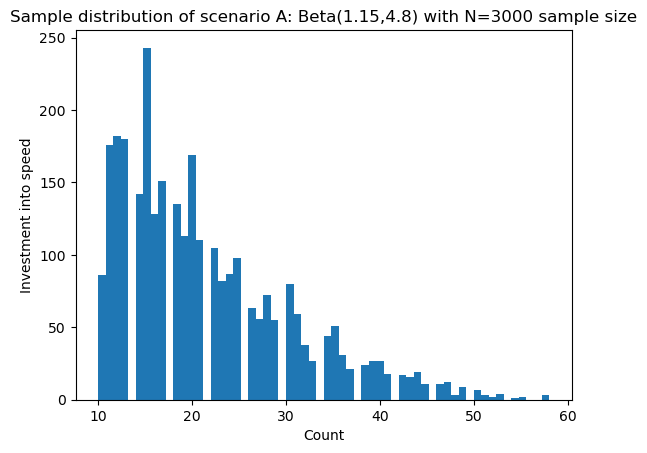

In [57]:
alpha = 1.15
beta = 4.8
N_sample = 3000
snap_prob = 0.08

# Plotting of a sample distribution under this scenario
test = sample_speed_distribution(alpha=alpha, beta=beta, N=N_sample, snap_to_5_prob=snap_prob)
plt.hist(test, bins=60)
plt.title(f"Sample distribution of scenario A: Beta({alpha},{beta}) with N={N_sample} sample size")
plt.xlabel("Count")
plt.ylabel("Investment into speed")

In [60]:
speed_bids = [5,8,10,13,15,18,20,23,25,28,30,32,35,38,40]
alpha = 1.15
beta = 4.8
N_sample = 3000
snap_prob = 0.08
N_runs = 2000

MC_results_A = []
# MAIN MC RUN - 2000 runs per bid
for speed_bid in track(speed_bids, description="Running MC:"):
    intermediate_results = []
    for _ in range(N_runs):
        
        # Sample and determine speed factor
        sampled_speed_bids = sample_speed_distribution(alpha=alpha, beta=beta, N=N_sample, snap_to_5_prob=snap_prob)
        speed_factor = compute_speed_factor(sampled_speed_bids, speed_bid)
        
        # Calculate total value and store in intermediate_results
        intermediate_results.append(research_scale_tradeoff(100-speed_bid,speed_factor))
    
    # Take the mean value of the runs and store it in MC_results
    MC_results_A.append(np.array(intermediate_results).mean(axis=0))    

Output()

#### Plotting of scenario A

##### Surface

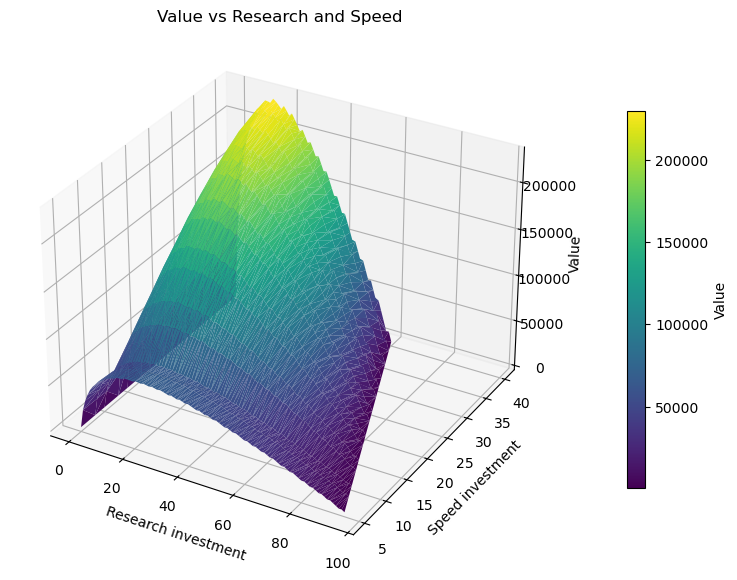

In [61]:
plot_irregular_surface(MC_results_A, speed_bids)

##### Scatter

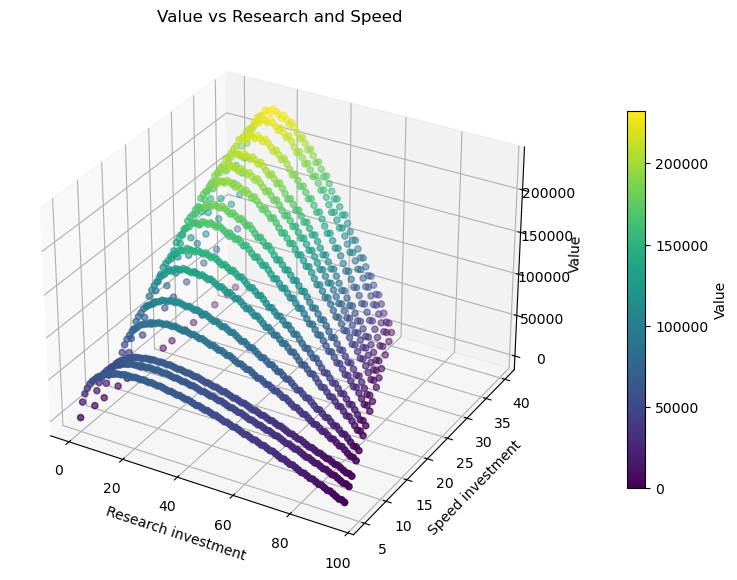

In [62]:
plot_irregular_scatter(MC_results_A, speed_bids)

### MC analysis scenario B: game-theoretic field

Text(0, 0.5, 'Investment into speed')

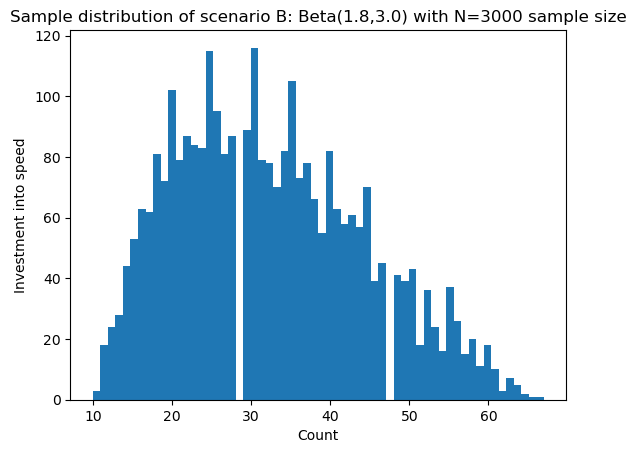

In [63]:
alpha = 1.8
beta = 3.0
N_sample = 3000
snap_prob = 0.08

# Plotting of a sample distribution under this scenario
test = sample_speed_distribution(alpha=alpha, beta=beta, N=N_sample, snap_to_5_prob=snap_prob)
plt.hist(test, bins=60)
plt.title(f"Sample distribution of scenario B: Beta({alpha},{beta}) with N={N_sample} sample size")
plt.xlabel("Count")
plt.ylabel("Investment into speed")

In [64]:
speed_bids = [5,8,10,13,15,18,20,23,25,28,30,32,35,38,40]
alpha = 1.8
beta = 3.0
N_sample = 3000
snap_prob = 0.08
N_runs = 2000

MC_results_B = []
# MAIN MC RUN - 1000 runs per bid
for speed_bid in track(speed_bids, description="Running MC:"):
    intermediate_results = []
    for _ in range(N_runs):
        
        # Sample and determine speed factor
        sampled_speed_bids = sample_speed_distribution(alpha=alpha, beta=beta, N=N_sample, snap_to_5_prob=snap_prob)
        speed_factor = compute_speed_factor(sampled_speed_bids, speed_bid)
        
        # Calculate total value and store in intermediate_results
        intermediate_results.append(research_scale_tradeoff(100-speed_bid,speed_factor))
    
    # Take the mean value of the runs and store it in MC_results
    MC_results_B.append(np.array(intermediate_results).mean(axis=0))  

Output()

#### Plotting of scenario B

##### Surface

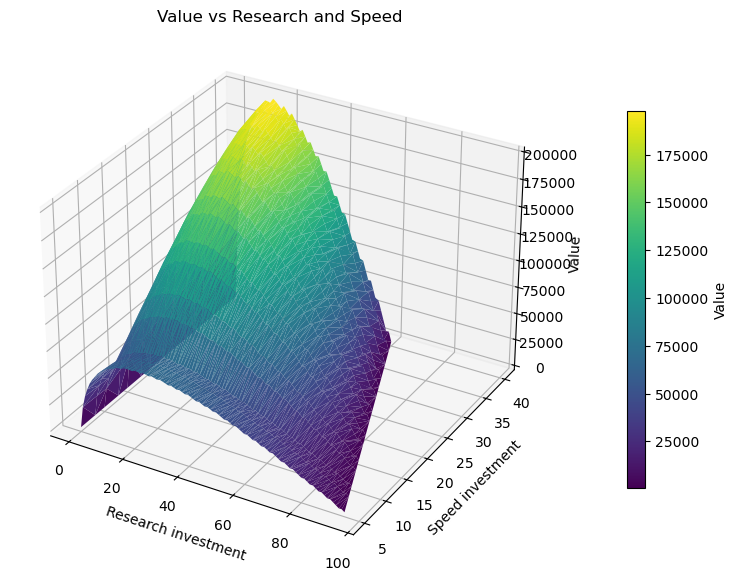

In [65]:
plot_irregular_surface(MC_results_B, speed_bids)

##### Scatter

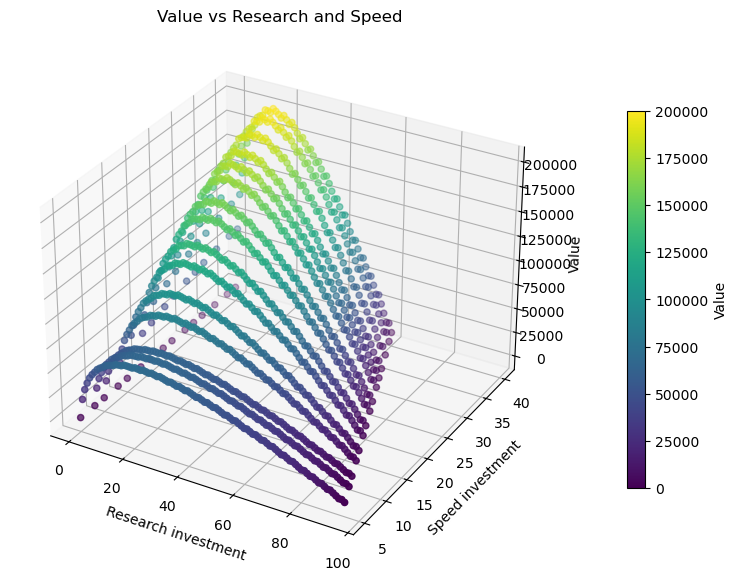

In [66]:
plot_irregular_scatter(MC_results_B, speed_bids)